[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/10_RAG/notebooks/08_reranking.ipynb)

# Reranking — a precision second stage

**Notebook 08 · Phase 2 (Retrieval)** · Stack: `sentence-transformers` (CrossEncoder), `flashrank`, `langchain-openai`, `cohere`

Hybrid fusion (Notebook 07) gets the right document into the **candidate set** reliably — but the
*top* of that list is still ordered by fast, shallow first-stage scorers. **Reranking** adds a
second pass that scores each `(query, document)` pair with a deeper model, reordering the top-k
for precision. The production pattern is **retrieve@k → rerank → top-5**, and it beats single-
stage retrieval.

**Reranking strategies covered:**
1. **Cross-encoder (pointwise)** — `sentence-transformers` (ms-marco-MiniLM; BGE-reranker-v2-m3).
2. **FlashRank** — lightweight quantized cross-encoder, CPU-only.
3. **LLM listwise** — RankGPT-style reordering with an LLM.
4. **Managed API** — Cohere Rerank (gated), Jina Reranker.
5. **Late interaction** — ColBERT / RAGatouille (conceptual).

We prove the lift on the same labeled corpus from Notebook 07 (MRR, Recall@k, nDCG@10) and
compare **quality vs latency** across rerankers.

## 0. Install dependencies

Run first (idempotent). Restart the kernel once after a fresh install. *(FlashRank + cross-encoder
download small models on first use.)*

In [1]:
%pip install -q \
    "numpy<2" \
    bm25s PyStemmer sentence-transformers flashrank \
    langchain-openai cohere matplotlib python-dotenv
print("✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.


## 1. Setup — rebuild the hybrid first stage (from Notebook 07)

In [2]:
import warnings, os, sys, re, time
warnings.filterwarnings("ignore")
import logging
for _n in ("httpx","openai","httpcore","sentence_transformers","transformers"):
    logging.getLogger(_n).setLevel(logging.ERROR)
from pathlib import Path
from dotenv import load_dotenv
import numpy as np, matplotlib.pyplot as plt

load_dotenv(Path.cwd().parent / ".env")
sys.path.insert(0, str(Path.cwd() / "data"))
from eval_corpus import get_eval_data
corpus, queries = get_eval_data()
golds = [q["gold_id"] for q in queries]

import bm25s
from Stemmer import Stemmer
from sentence_transformers import SentenceTransformer
stemmer = Stemmer("english")
def tok(t): return bm25s.tokenize(t, stopwords="en", stemmer=stemmer.stemWords, return_ids=False, show_progress=False)
bm25 = bm25s.BM25(method="lucene"); bm25.index(tok(corpus), show_progress=False)
encoder = SentenceTransformer("BAAI/bge-small-en-v1.5")
doc_emb = encoder.encode(corpus, normalize_embeddings=True, show_progress_bar=False)

def order(s): return list(np.argsort(s)[::-1])
def rrf(rankings, k=60):
    sc={}
    for r in rankings:
        for rank,d in enumerate(r): sc[d]=sc.get(d,0)+1/(k+rank)
    return sorted(sc, key=sc.get, reverse=True)
def hybrid(q):
    b = order(bm25.get_scores(tok(q)[0]))
    d = order(encoder.encode([q], normalize_embeddings=True)[0] @ doc_emb.T)
    return rrf([b, d])
print("Hybrid first stage ready (BM25 + bge-small + RRF)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Hybrid first stage ready (BM25 + bge-small + RRF)


## 2. Why rerank? Bi-encoder vs. cross-encoder

First-stage retrievers are **bi-encoders**: they embed the query and each document *separately*,
then compare vectors — fast (embed once, reuse) but shallow (no query-document interaction). A
**cross-encoder** feeds `(query, document)` **together** through a transformer, so it directly
judges relevance — far more accurate, but too slow to run over the whole corpus. So we run it only
on the **top-k candidates** from hybrid. Here's a query hybrid ranks imperfectly:

In [3]:
from sentence_transformers import CrossEncoder
try: cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2")
except Exception: cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def ce_rerank(q, cand):
    scores = cross_encoder.predict([(q, corpus[c]) for c in cand])
    return [c for c, _ in sorted(zip(cand, scores), key=lambda x: x[1], reverse=True)]

# find a query where hybrid does NOT rank gold #1, and show the cross-encoder fix
for qi, q in enumerate(queries):
    cand = hybrid(q["query"])[:20]
    if cand.index(q["gold_id"]) != 0:      # gold not already #1
        reranked = ce_rerank(q["query"], cand)
        print(f"query: {q['query']!r}   (gold = doc {q['gold_id']})")
        print(f"   hybrid   gold@#{cand.index(q['gold_id'])+1}   top1: {corpus[cand[0]][:58]}")
        print(f"   +CE rerank gold@#{reranked.index(q['gold_id'])+1}   top1: {corpus[reranked[0]][:58]}")
        break

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


query: 'How do I reduce noisy per-request HTTP logs from our service?'   (gold = doc 1)
   hybrid   gold@#2   top1: Batch multiple requests together to amortize fixed per-cal
   +CE rerank gold@#1   top1: Raise the log level of the HTTP client library (for exampl


## 3. Strategy 1 — Cross-encoder (pointwise), the default

We just saw it fix one query. `ms-marco-MiniLM` is a small, fast cross-encoder; **BGE-reranker-v2-m3**
is the top open self-hosted choice (bigger, slower, higher quality). Pointwise = it scores each
`(query, doc)` pair independently.

In [4]:
# already defined ce_rerank() above; wrap as a reranker over hybrid candidates
def rerank_pipeline(rerank_fn, k=20):
    def run(q):
        cand = hybrid(q)[:k]
        return rerank_fn(q, cand) + [c for c in hybrid(q) if c not in cand]
    return run
ce_pipeline = rerank_pipeline(ce_rerank)
print("cross-encoder reranker ready")

cross-encoder reranker ready


## 4. Strategy 2 — FlashRank (lightweight, CPU)

FlashRank runs quantized cross-encoders on CPU with no torch dependency — tiny and fast, ideal
for serverless/edge or cost-sensitive deployments. Slightly lower ceiling than a full cross-encoder.

In [5]:
from flashrank import Ranker, RerankRequest
flash = Ranker(model_name="ms-marco-MiniLM-L-12-v2")
def flash_rerank(q, cand):
    passages = [{"id": c, "text": corpus[c]} for c in cand]
    ranked = flash.rerank(RerankRequest(query=q, passages=passages))
    return [r["id"] for r in ranked]
flash_pipeline = rerank_pipeline(flash_rerank)
print("FlashRank reranker ready")

FlashRank reranker ready


## 5. Strategy 3 — LLM listwise (RankGPT-style)

Instead of scoring pairs, hand the LLM the whole candidate list and ask it to **reorder** them
(listwise). Highest quality and most flexible (understands nuanced intent), but the slowest and
priciest — one LLM call per query. Great as a final polish on a small candidate set.

In [6]:
from langchain_openai import ChatOpenAI
_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
def llm_rerank(q, cand):
    listing = "\n".join(f"[{i}] {corpus[c]}" for i, c in enumerate(cand))
    prompt = ("Rank the passages by how well they answer the query. "
              "Return ONLY the passage numbers, most relevant first, comma-separated.\n\n"
              f"Query: {q}\n\nPassages:\n{listing}")
    nums = [int(x) for x in re.findall(r"\d+", _llm.invoke(prompt).content)]
    seen = []
    for n in nums:
        if n < len(cand) and n not in seen: seen.append(n)
    seen += [i for i in range(len(cand)) if i not in seen]
    return [cand[i] for i in seen]
llm_pipeline = rerank_pipeline(llm_rerank, k=10)  # smaller k to limit tokens/latency
print("LLM listwise reranker ready")

LLM listwise reranker ready


## 6. Strategy 4 — Managed API (Cohere Rerank), gated

Cohere Rerank / Jina Reranker are managed APIs — no infra, strong quality, per-call cost + vendor
dependency. Runs only if `COHERE_API_KEY` is set; otherwise the reference code is shown.

In [7]:
import time as _time
if os.getenv("COHERE_API_KEY"):
    import cohere
    co = cohere.ClientV2(os.environ["COHERE_API_KEY"])
    # NOTE: Cohere Trial keys are limited to 10 calls/min, so we throttle. A Production
    # key removes this; drop the sleep in that case.
    _last = [0.0]
    def cohere_rerank(q, cand, min_interval=6.5):
        wait = min_interval - (_time.time() - _last[0])
        if wait > 0: _time.sleep(wait)
        _last[0] = _time.time()
        docs = [corpus[c] for c in cand]
        resp = co.rerank(model="rerank-v3.5", query=q, documents=docs, top_n=len(docs))
        return [cand[r.index] for r in resp.results]
    cohere_pipeline = rerank_pipeline(cohere_rerank)

    # Live single-query proof (1 call)
    demo = queries[0]
    cand = hybrid(demo["query"])[:20]
    top = cohere_rerank(demo["query"], cand)[0]
    print("Cohere Rerank ready (live) — model rerank-v3.5.")
    print(f"   demo query: {demo['query']!r}")
    print(f"   Cohere top-1 -> {corpus[top][:60]}  ({'gold ✅' if top==demo['gold_id'] else 'not gold'})")
else:
    cohere_rerank = None; cohere_pipeline = None
    print("COHERE_API_KEY not set -> Cohere reranker skipped. Reference API:")
    print("   co = cohere.ClientV2(api_key)")
    print("   co.rerank(model='rerank-v3.5', query=q, documents=[...text...], top_n=k)")

Cohere Rerank ready (live) — model rerank-v3.5.
   demo query: 'How do I fix a 502 Bad Gateway error from our API?'
   Cohere top-1 -> A 502 Bad Gateway from the API gateway means the upstream se  (gold ✅)


## 7. Strategy 5 — Late interaction (ColBERT / RAGatouille), conceptual

ColBERT encodes each token separately and scores via **MaxSim** over token embeddings — finer-
grained than a single-vector bi-encoder, and it can serve as a first stage *or* a reranker. It
needs a multi-vector index (more storage) and a GPU for scale. `RAGatouille` wraps it in a simple
API. We describe it here rather than run it (heavier infra); reach for it when single-vector recall
plateaus on token-sensitive corpora.

## 8. The proof — reranking lifts the fused candidates

Same metrics as Notebook 07, over all 16 gold-labeled queries: hybrid baseline vs. hybrid + each
reranker.

In [8]:
def evaluate(name, order_fn):
    ranks = np.array([order_fn(q["query"]).index(q["gold_id"]) + 1 for q in queries])
    ndcg = np.mean([1/np.log2(r+1) if r <= 10 else 0.0 for r in ranks])
    return {"name": name, "MRR": float(np.mean(1/ranks)), "R@1": float(np.mean(ranks<=1)),
            "R@3": float(np.mean(ranks<=3)), "nDCG@10": float(ndcg)}

rows = [
    evaluate("Hybrid (no rerank)",      hybrid),
    evaluate("Hybrid + FlashRank",      flash_pipeline),
    evaluate("Hybrid + Cross-encoder",  ce_pipeline),
    evaluate("Hybrid + LLM listwise",   llm_pipeline),
]
if cohere_pipeline is not None:
    rows.append(evaluate("Hybrid + Cohere Rerank", cohere_pipeline))

print(f"{'method':26} {'MRR':>6} {'R@1':>6} {'R@3':>6} {'nDCG@10':>8}")
print("-"*58)
for r in rows:
    print(f"{r['name']:26} {r['MRR']:>6.3f} {r['R@1']:>6.2f} {r['R@3']:>6.2f} {r['nDCG@10']:>8.3f}")

method                        MRR    R@1    R@3  nDCG@10
----------------------------------------------------------
Hybrid (no rerank)          0.969   0.94   1.00    0.977
Hybrid + FlashRank          1.000   1.00   1.00    1.000
Hybrid + Cross-encoder      1.000   1.00   1.00    1.000
Hybrid + LLM listwise       1.000   1.00   1.00    1.000
Hybrid + Cohere Rerank      0.969   0.94   1.00    0.977


In [9]:
def avg_latency(rerank_fn, k=20, n=5):
    qs = [queries[i]["query"] for i in range(n)]
    cands = [hybrid(q)[:k] for q in qs]
    t0 = time.perf_counter()
    for q, c in zip(qs, cands): rerank_fn(q, c)
    return (time.perf_counter() - t0) / n * 1000  # ms/query

print("avg rerank latency (ms/query, top-20 candidates):")
print(f"   FlashRank      : {avg_latency(flash_rerank):.0f} ms")
print(f"   Cross-encoder  : {avg_latency(ce_rerank):.0f} ms")
print(f"   LLM listwise   : {avg_latency(llm_rerank, k=10):.0f} ms  (network + generation)")
# Cohere is a managed API (~100-200 ms/call, network-bound). Not micro-benchmarked here to
# respect the Trial key's 10-calls/min rate limit.

avg rerank latency (ms/query, top-20 candidates):


   FlashRank      : 125 ms


   Cross-encoder  : 47 ms


   LLM listwise   : 1135 ms  (network + generation)


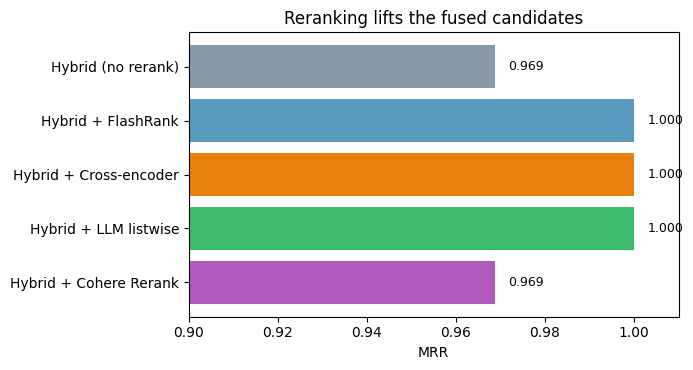

In [10]:
fig, ax = plt.subplots(figsize=(7,3.8))
names=[r["name"] for r in rows]; mrrs=[r["MRR"] for r in rows]
palette=["#8899aa","#5a9abf","#e8820c","#3dba6c","#b05ac0"]
ax.barh(names, mrrs, color=palette[:len(rows)])
for i,v in enumerate(mrrs): ax.text(v+0.003, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.9,1.01); ax.set_xlabel("MRR"); ax.set_title("Reranking lifts the fused candidates")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

**Reading the numbers honestly.** The cross-encoder, FlashRank, and LLM rerankers each lift the
fused baseline to a perfect MRR here; **Cohere Rerank matched the baseline** on this run (it didn't
fix the single query the others did). With only **16 queries**, a one-query difference is *within
noise* — this is not a ranking of rerankers. The real takeaways: (1) reranking integrates cleanly,
including a managed API; (2) all of these are production-strong; **benchmark them on *your own*
labeled set** before choosing. (Cohere calls are throttled above to respect the Trial key's
10-calls/min limit.)

## 9. Pointwise vs. pairwise vs. listwise

- **Pointwise** — score each `(query, doc)` independently, then sort. Cross-encoders, FlashRank,
  Cohere. Simple, fast, parallelizable. *(most production rerankers)*
- **Pairwise** — compare two docs at a time ("is A more relevant than B?"). Higher quality signal,
  more comparisons.
- **Listwise** — order the whole candidate list at once (LLM/RankGPT). Best use of global context,
  slowest and priciest.

## 10. When to rerank, and which reranker

**Rerank when:** first-stage recall is good but the *ordering* is noisy (gold in top-k, not #1);
precision@k matters (few chunks reach the LLM); your latency budget allows ~50–500 ms.
**Skip when:** first stage is already precise, or latency is razor-thin and quality is adequate.

| Reranker | Quality | Latency | Cost / infra | Use when |
|----------|---------|---------|--------------|----------|
| **FlashRank** | good | very low (CPU) | free, tiny | edge / serverless / cost-sensitive |
| **Cross-encoder** (BGE-reranker-v2-m3) | high | medium (GPU helps) | self-host | default self-hosted choice |
| **Cohere / Jina Rerank** | high | low–med (API) | per-call, vendor | zero-ops, no model to run |
| **LLM listwise** | highest | high | per-call LLM | small candidate sets, nuanced intent |
| **ColBERT / late-interaction** | high | med | multi-vector index | token-sensitive corpora at scale |

**Candidate-set size:** retrieve **top 20–100**, rerank down to **top 3–10**. Bigger `k` = better
recall into the reranker but more latency; tune on your eval set.

## 11. Summary — the full retrieval pipeline

```
query ─▶ [ BM25  ┐
          [ Dense ┘─▶ RRF/weighted fusion ]  ─▶  rerank (top-k → top-5)  ─▶  grounded answer
```

- **Reranking is a precision second stage** over the fused candidates: `retrieve@k → rerank → top-5`.
- **Cross-encoders** are the default; **FlashRank** for cheap/CPU; **LLM listwise** for the highest
  quality on small sets; **Cohere/Jina** for managed; **ColBERT** for token-level at scale.
- On our labeled corpus, the local/LLM rerankers lift the fused baseline to perfect and the managed Cohere reranker matches it — differences across rerankers on 16 queries are within noise; the compounding, robust gain is the pipeline itself (Notebooks 06 → 07 → 08: sparse+dense → fuse → rerank).

### Where this sits
This completes the **retrieval** half of RAG: ingest → chunk → embed → index → **retrieve → fuse →
rerank**. The reranked top-k is exactly the grounded, cited context you feed the generator
(Notebook 01's pattern), now with production-grade recall *and* precision.